In [ ]:
# imports

# ! pip install pandas kaggle scikit-learn matplotlib timm

import os
import zipfile

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms

2.11.0+cpu
1.0.26


   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 2.1 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.2 MB 2.1 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.2 MB 2.0 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.2 MB 2.1 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.2 MB 2.1 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.2 MB 2.1 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 2.1 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.2 MB 2.1 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.2 MB 2.1 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.2 MB 2.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.2 MB 2.1 MB/s eta 0:00:02
   -----------------------

In [ ]:
# =========================
# 1. KAGGLE SETUP
# set up kaggle API credentials to download the dataset
# i use my own kaggle account and API token, you should replace these with your own credentials
# i will leave my token here, i know it's not a good practice and a security risk, but i will easily revoke the token after this project
# =========================

os.environ['KAGGLE_USERNAME'] = 'throwawayssss'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_a825473d4e50779fcd4632114d4f7628'

In [ ]:
# =========================
# 2. DATA ACQUISITION
# =========================
# check if data directory already exists to avoid redundant downloads/unzipping
if not os.path.exists("data"):
    # download the dataset directly from Kaggle
    !kaggle competitions download -c iivp-2026-challenge

    # extract all files from the downloaded zip into the 'data' directory
    with zipfile.ZipFile("iivp-2026-challenge.zip", "r") as zip_ref:
        zip_ref.extractall("./data")


# =========================
# 3. DATASET DEFINITION
# =========================
class IIVPDataset(Dataset):

    """
    Custom PyTorch Dataset for the IIVP challenge.
    Handles mapping CSV metadata to image files on disk.
    """

    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

        # pre-scan the directory to map Image IDs to their full system paths
        self.image_paths = {}
        for root, dirs, files in os.walk(img_dir):
            for file in files:
                if file.endswith(".png"):
                    image_id = file.replace(".png", "")
                    self.image_paths[image_id] = os.path.join(root, file)

    def __len__(self):
        # returns the total number of samples in the dataframe
        return len(self.df)

    def __getitem__(self, idx):

        """
        Loads and processes a single data point (image + label/id).
        """

        # retrieve image ID from the dataframe and sanitize it
        img_id = str(self.df.iloc[idx]["Id"])
        img_id = img_id.replace(".png", "")

        # fetch the pre-cached path 
        img_path = self.image_paths.get(img_id)

        if img_path is None:
            raise FileNotFoundError(f"Could not find image with Id: {img_id}")

        # load image and ensure it is in 3-channel RGB format
        image = Image.open(img_path).convert("RGB")

        # apply augmentation/preprocessing if provided
        if self.transform:
            image = self.transform(image)

        # return (image, id) for inference, or (image, label) for training
        if self.is_test:
            return image, img_id

        label = int(self.df.iloc[idx]["Category"])
        return image, label



  0%|          | 0.00/14.6M [00:00<?, ?B/s]
  7%|▋         | 1.00M/14.6M [00:00<00:07, 1.88MB/s]
 14%|█▎        | 2.00M/14.6M [00:00<00:03, 3.63MB/s]
 27%|██▋       | 4.00M/14.6M [00:00<00:01, 6.83MB/s]
 41%|████      | 6.00M/14.6M [00:00<00:00, 9.35MB/s]
 55%|█████▍    | 8.00M/14.6M [00:01<00:00, 11.4MB/s]
 68%|██████▊   | 10.0M/14.6M [00:01<00:00, 12.3MB/s]
 82%|████████▏ | 12.0M/14.6M [00:01<00:00, 13.7MB/s]
 96%|█████████▌| 14.0M/14.6M [00:01<00:00, 14.3MB/s]
100%|██████████| 14.6M/14.6M [00:01<00:00, 9.99MB/s]


In [ ]:
# =========================
# 4. MODEL SETUP
# =========================

# using 'timm' (torch image models) to load a ConvNeXt-Tiny architecture.
model_name = "convnext_tiny"
model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=10
)

# automatically resolve the specific preprocessing (mean, std, resolution) the model expects
data_config = timm.data.resolve_data_config({}, model=model)

# create standard training transforms (includes random cropping/flipping for augmentation)
train_transform = timm.data.create_transform(
    **data_config,
    is_training=True
)

# create validation/test transforms (resize and center crop only, no random distortions)
val_transform = timm.data.create_transform(
    **data_config,
    is_training=False
)

test_transform = val_transform


# =========================
# 5. LOAD TRAIN / VALIDATION DATA
# =========================
train_df_full = pd.read_csv("./data/train.csv")

# --- STEP 1: sync CSV with file system ---
# some datasets have missing images; scan the disk to find what is actually available.
existing_ids = set()

for root, dirs, files in os.walk("./data/train/train/"):
    for file in files:
        if file.endswith(".png"):
            existing_ids.add(file.replace(".png", ""))

print("Images found:", len(existing_ids))
print("Rows before filtering:", len(train_df_full))

# clean and normalize the ID column to match filenames
train_df_full["Id"] = train_df_full["Id"].astype(str).str.replace(".png", "", regex=False)

# filter the dataframe: remove any rows where the image file is not on disk
train_df_full = train_df_full[
    train_df_full["Id"].isin(existing_ids)
].reset_index(drop=True)

print("After missing-image filter:", len(train_df_full))


# --- STEP 2: remove corrupt images ---

# opening every image with PIL to verify integrity before starting the training loop.
valid_ids = set()

for root, dirs, files in os.walk("./data/train/train/"):
    for file in files:
        if file.endswith(".png"):
            path = os.path.join(root, file)
            image_id = file.replace(".png", "")

            try:
                with Image.open(path) as img:
                    img.verify() # check for file integrity
                valid_ids.add(image_id)
            except UnidentifiedImageError:
                print("Corrupt image skipped:", path)

print("After corrupt-image scan (before filtering):", len(train_df_full))

# final filtering: keep only rows that exist and are not corrupt
train_df_full = train_df_full[
    train_df_full["Id"].isin(valid_ids)
].reset_index(drop=True)

print("Final usable rows:", len(train_df_full))

# split data into 80% training and 20% validation 
# batch size is set to 32, following common practice for training deep learning models, balancing between computational efficiency and convergence stability.
train_df, val_df = train_test_split(
    train_df_full,
    test_size=0.2,
    random_state=42,
    stratify=train_df_full["Category"]
)

# instantiate the custom dataset class defined earlier
train_dataset = IIVPDataset(
    df=train_df,
    img_dir="./data/train/train/",
    transform=train_transform,
    is_test=False
)

val_dataset = IIVPDataset(
    df=val_df,
    img_dir="./data/train/train/",
    transform=val_transform,
    is_test=False
)

# dataloaders handle batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# --- SANITY CHECK: PRINT FIRST ROW INFO ---

row = train_df.iloc[0]

img_id = str(row["Id"])
label = int(row["Category"])

img_path = os.path.join("./data/train/train/", str(label), f"{img_id}.png")

print("Id:", img_id)
print("Label:", label)
print("Path:", img_path)
print("Exists:", os.path.exists(img_path))


# =========================
# 6. TRAIN MODEL
# =========================

# set computation to GPU (cuda) if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model.to(device)

criterion = nn.CrossEntropyLoss()
# using AdamW optimizer. learning rate is set to 1e-4, which is a common practice for AdamW as a starting point.
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

best_val_acc = 0.0
num_epochs = 10

for epoch in range(num_epochs):
    # --- training phase ---
    model.train()
    train_loss = 0.0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- validation phase ---
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad(): # disable gradient calculation for speed and memory efficiency 
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    #  save the model only if validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_convnext_tiny.pth")
        print("Saved best model")


# =========================
# 7. LOAD BEST MODEL
# =========================

# load the weights from the highest-performing epoch for final testing
model.load_state_dict(
    torch.load("best_convnext_tiny.pth", map_location=device)
)
model.eval()

print("Best validation accuracy:", best_val_acc)


# =========================
# 8. DETAILED VALIDATION RESULTS
# =========================

# generate a comprehensive report (precision, recall, F1) on the validation set
y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred))


# =========================
# 9. LOAD TEST DATA
# =========================
test_df = pd.read_csv("./data/test.csv")

test_dataset = IIVPDataset(
    df=test_df,
    img_dir="./data/test/test/",
    transform=test_transform,
    is_test=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# =========================
# 10. PRINT TEST PREDICTIONS
# =========================
test_predictions = []

with torch.no_grad():
    for imgs, ids in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        for img_id, pred in zip(ids, preds):
            test_predictions.append({
                "Id": img_id,
                "PredictedCategory": int(pred)
            })

pred_df = pd.DataFrame(test_predictions)

print(pred_df.head(20))

Images found: 17000
Rows before filtering: 17000
After missing-image filter: 17000
After corrupt-image scan (before filtering): 17000
Final usable rows: 17000
Id: 12387
Label: 0
Path: ./data/train/train/0\12387.png
Exists: True
Using device: cpu
Epoch 1/10 | Train Loss: 0.7751 | Val Acc: 0.9882
Saved best model
Epoch 2/10 | Train Loss: 0.4147 | Val Acc: 0.9888
Saved best model
Epoch 3/10 | Train Loss: 0.3716 | Val Acc: 0.9865
Epoch 4/10 | Train Loss: 0.3446 | Val Acc: 0.9897
Saved best model
Epoch 5/10 | Train Loss: 0.3276 | Val Acc: 0.9932
Saved best model
Epoch 6/10 | Train Loss: 0.3070 | Val Acc: 0.9806
Epoch 7/10 | Train Loss: 0.2949 | Val Acc: 0.9935
Saved best model
Epoch 8/10 | Train Loss: 0.2860 | Val Acc: 0.9959
Saved best model
Epoch 9/10 | Train Loss: 0.2699 | Val Acc: 0.9956
Epoch 10/10 | Train Loss: 0.2782 | Val Acc: 0.9926
Best validation accuracy: 0.9958823529411764
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       3

Pred: 3 | True: 3
Pred: 3 | True: 3
Pred: 8 | True: 8
Pred: 4 | True: 4
Pred: 7 | True: 7
Pred: 5 | True: 5
Pred: 1 | True: 1
Pred: 6 | True: 6
Pred: 0 | True: 0
Pred: 3 | True: 3


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


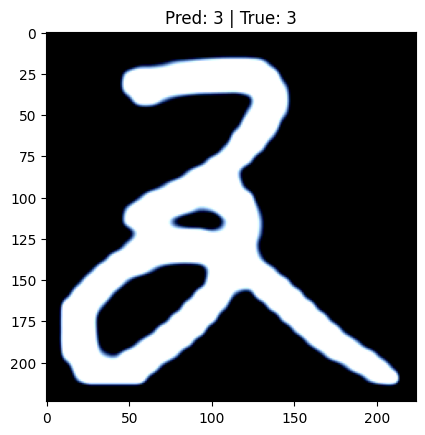

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


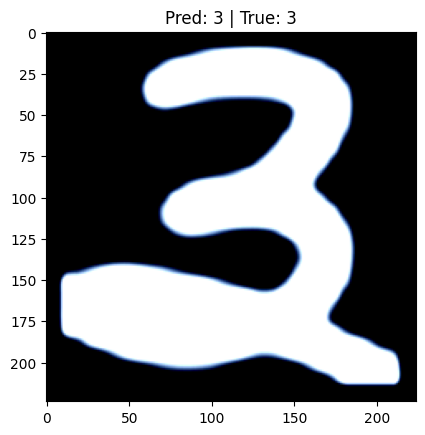

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


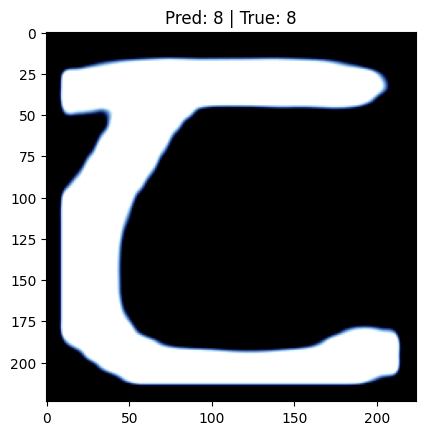

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


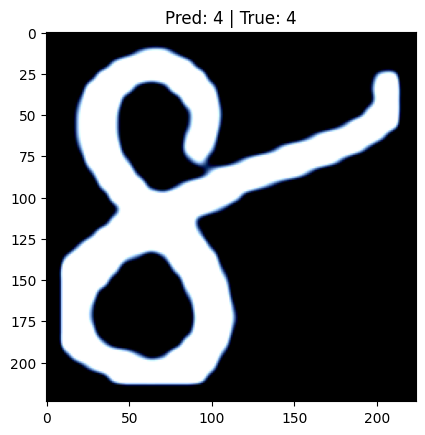

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


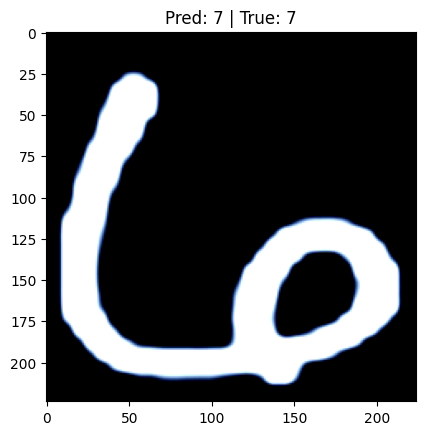

In [ ]:
# visualizing validation images with predicted and true labels

for i in range(10):
    print("Pred:", y_pred[i], "| True:", y_true[i])

model.eval()

imgs, labels = next(iter(val_loader))
imgs = imgs.to(device)

outputs = model(imgs)
preds = outputs.argmax(dim=1)

for i in range(5):
    img = imgs[i].cpu().permute(1, 2, 0)
    plt.imshow(img)
    plt.title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
    plt.show()